In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv("daily_trending_videos.csv")
df.head()

,video_id,title,channel,country,views,likes,comments,published_at,fetch_date
0,KDorKy-13ak,Kendrick Lamar's Apple Music Super Bowl Halfti...,NFL,US,33079510.0,1633864.0,98574.0,2025-02-10T03:22:55Z,11-02-2025 17:43
1,lI4dq7ffQy0,Kendrick Lamar Disses Drake During Halftime Sh...,E! News,US,1475936.0,12629.0,5126.0,2025-02-10T03:27:44Z,11-02-2025 17:43
2,Y5vgBxUuNlc,JAZZ at LAKERS | FULL GAME HIGHLIGHTS | Februa...,NBA,US,1841263.0,31666.0,2906.0,2025-02-11T06:12:20Z,11-02-2025 17:43
3,hUUszE29jS0,Marvel Studios’ Thunderbolts* | Big Game Trail...,Marvel Entertainment,US,9893431.0,204063.0,13864.0,2025-02-09T23:54:00Z,11-02-2025 17:43
4,jdX5xwV829s,The First Kiss in Brawl Stars!?,Brawl Stars,US,8354717.0,257108.0,17632.0,2025-02-10T08:58:00Z,11-02-2025 17:43


In [ ]:
df.shape

(110001, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110001 entries, 0 to 110000
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   video_id      110001 non-null  object 
 1   title         110001 non-null  object 
 2   channel       110000 non-null  object 
 3   country       110000 non-null  object 
 4   views         110000 non-null  float64
 5   likes         110000 non-null  float64
 6   comments      110000 non-null  float64
 7   published_at  110000 non-null  object 
 8   fetch_date    110000 non-null  object 
dtypes: float64(3), object(6)
memory usage: 7.6+ MB


In [ ]:
df.isnull().sum()

,0
video_id,0
title,0
channel,1
country,1
views,1
likes,1
comments,1
published_at,1
fetch_date,1


In [ ]:
df = df.drop_duplicates()

In [ ]:
if "tags" in df.columns:
    df["tags"] = df["tags"].fillna("No Tags")

In [ ]:
df["published_at"] = pd.to_datetime(df["published_at"]).dt.tz_localize(None)
df["fetch_date"] = pd.to_datetime(df["fetch_date"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)

In [ ]:
df.columns

Index(['video_id', 'title', 'channel', 'country', 'views', 'likes', 'comments',
       'published_at', 'fetch_date'],
      dtype='object')

In [ ]:
df["trending_duration"] = (df["fetch_date"] - df["published_at"]).dt.days

In [ ]:
df["engagement_ratio"] = (df["likes"] + df["comments"]) / df["views"]

/tmp/ipython-input-2511/802971419.py:14: UserWarning: Glyph 129425 (\N{SQUID}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2511/802971419.py:14: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129425 (\N{SQUID}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


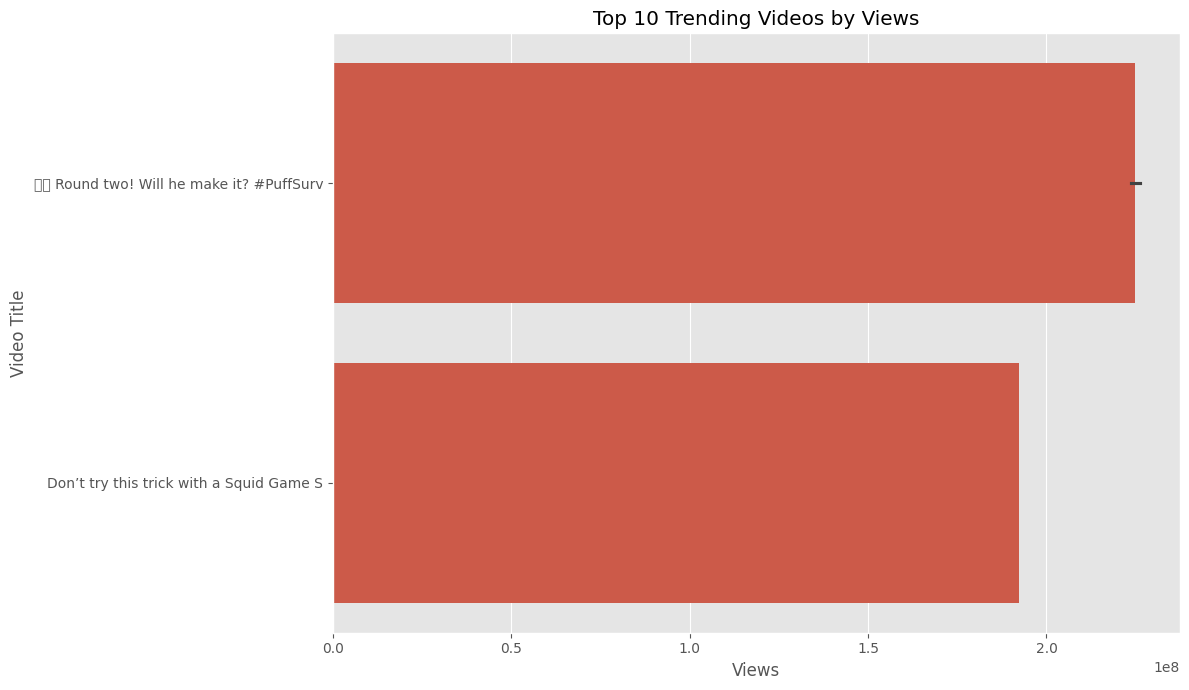

In [ ]:
top_videos = df.sort_values(by="views", ascending=False).head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x="views",
    y=top_videos["title"].str.slice(0,40),  # shorten titles
    data=top_videos
)

plt.title("Top 10 Trending Videos by Views")
plt.xlabel("Views")
plt.ylabel("Video Title")
plt.tight_layout()
plt.show()

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df["sentiment_score"] = df["title"].apply(get_sentiment)

df.head()

,video_id,title,channel,country,views,likes,comments,published_at,fetch_date,trending_duration,engagement_ratio,sentiment_score
0,KDorKy-13ak,Kendrick Lamar's Apple Music Super Bowl Halfti...,NFL,US,33079510.0,1633864.0,98574.0,2025-02-10 03:22:55,2025-02-11 17:43:00,1.0,0.052372,0.333333
1,lI4dq7ffQy0,Kendrick Lamar Disses Drake During Halftime Sh...,E! News,US,1475936.0,12629.0,5126.0,2025-02-10 03:27:44,2025-02-11 17:43:00,1.0,0.012030,0.416667
2,Y5vgBxUuNlc,JAZZ at LAKERS | FULL GAME HIGHLIGHTS | Februa...,NBA,US,1841263.0,31666.0,2906.0,2025-02-11 06:12:20,2025-02-11 17:43:00,0.0,0.018776,-0.025000
3,hUUszE29jS0,Marvel Studios’ Thunderbolts* | Big Game Trail...,Marvel Entertainment,US,9893431.0,204063.0,13864.0,2025-02-09 23:54:00,2025-02-11 17:43:00,1.0,0.022027,-0.200000
4,jdX5xwV829s,The First Kiss in Brawl Stars!?,Brawl Stars,US,8354717.0,257108.0,17632.0,2025-02-10 08:58:00,2025-02-11 17:43:00,1.0,0.032884,0.312500


In [ ]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(label_sentiment)

df["sentiment"].value_counts()

,count
sentiment,
Neutral,83906
Positive,18305
Negative,7790


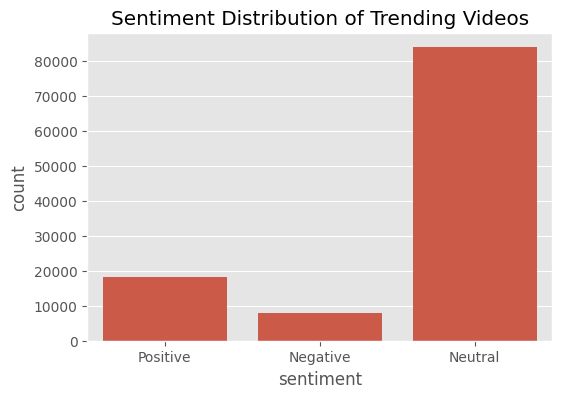

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution of Trending Videos")
plt.show()

In [ ]:
df.columns

Index(['video_id', 'title', 'channel', 'country', 'views', 'likes', 'comments',
       'published_at', 'fetch_date', 'trending_duration', 'engagement_ratio',
       'sentiment_score', 'sentiment'],
      dtype='object')

# Version 1: Initial Dataset (Single Country Dataset)

This dataset did not contain category information.

Analysis completed:
- Sentiment analysis on titles
- Engagement ratio calculation
- Channel analysis
- Country comparison

Limitation:
- No category/genre column
- Cannot perform category ranking via SQL

# Version 2: Multi-Country YouTube Trending Dataset

Dataset: datasnaek/youtube-new (Kaggle)

This version supports:
- Multi-country comparison
- Category/genre analysis
- SQL ranking by average views
- Time-series trending duration
- Tableau dashboard development

In [ ]:
import pandas as pd

us = pd.read_csv("USvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')
in_df = pd.read_csv("INvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')
gb = pd.read_csv("GBvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')
ca = pd.read_csv("CAvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')

print("US shape:", us.shape)
print("India shape:", in_df.shape)
print("UK shape:", gb.shape)
print("Canada shape:", ca.shape)

US shape: (2960, 16)
India shape: (1405, 16)
UK shape: (718, 16)
Canada shape: (14229, 16)


In [ ]:
us["region"] = "US"
in_df["region"] = "India"
gb["region"] = "UK"
ca["region"] = "Canada"

In [ ]:
df = pd.concat([us, in_df, gb, ca], ignore_index=True)

df.shape

(19312, 17)

In [ ]:
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m").dt.tz_localize(None)
df["publish_time"] = pd.to_datetime(df["publish_time"]).dt.tz_localize(None)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["tags"] = df["tags"].fillna("No Tags")

In [ ]:
df["trending_duration"] = (df["trending_date"] - df["publish_time"]).dt.days

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19312 entries, 0 to 19311
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   video_id                19312 non-null  object        
 1   trending_date           19312 non-null  datetime64[ns]
 2   title                   19312 non-null  object        
 3   channel_title           19311 non-null  object        
 4   category_id             19311 non-null  float64       
 5   publish_time            19311 non-null  datetime64[ns]
 6   tags                    19312 non-null  object        
 7   views                   19311 non-null  float64       
 8   likes                   19311 non-null  float64       
 9   dislikes                19311 non-null  float64       
 10  comment_count           19311 non-null  float64       
 11  thumbnail_link          19311 non-null  object        
 12  comments_disabled       19310 non-null  object

In [ ]:
df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'region', 'trending_duration'],
      dtype='object')

In [2]:
import json

with open("US_category_id.json") as f:
    category_data = json.load(f)

category_dict = {}

for item in category_data["items"]:
    category_dict[int(item["id"])] = item["snippet"]["title"]

category_dict

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [5]:
import pandas as pd

us = pd.read_csv("USvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')
in_df = pd.read_csv("INvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')
gb = pd.read_csv("GBvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')
ca = pd.read_csv("CAvideos.csv", on_bad_lines='skip', engine='python', encoding='latin1')

us["region"] = "US"
in_df["region"] = "India"
gb["region"] = "UK"
ca["region"] = "Canada"

df = pd.concat([us, in_df, gb, ca], ignore_index=True)

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,region
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,US
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US


In [6]:
df["category_name"] = df["category_id"].map(category_dict)

df[["category_id", "category_name"]].head()

,category_id,category_name
0,22,People & Blogs
1,24,Entertainment
2,23,Comedy
3,24,Entertainment
4,24,Entertainment


In [7]:
category_views = df.groupby("category_name")["views"].mean().sort_values(ascending=False)

category_views.head(10)

,views
category_name,
Music,8.435177e+06
Movies,3.007296e+06
Film & Animation,2.596421e+06
Nonprofits & Activism,1.975326e+06
Entertainment,1.628033e+06
Sports,1.595446e+06
Science & Technology,1.519962e+06
Gaming,1.345976e+06
Comedy,1.255354e+06


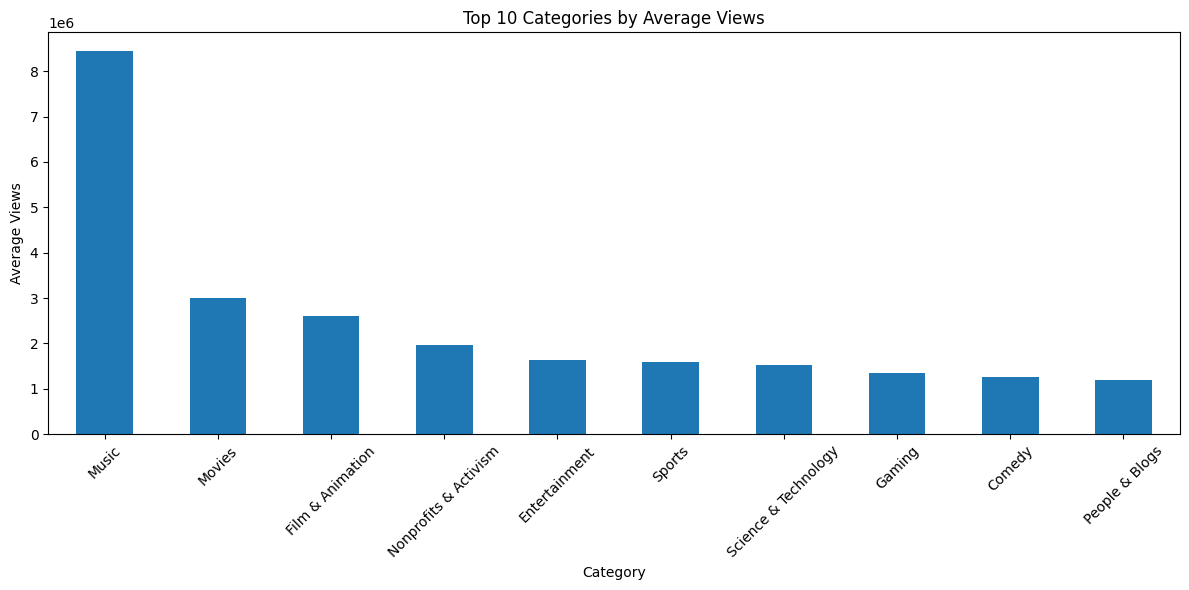

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
category_views.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average Views")
plt.xlabel("Category")
plt.ylabel("Average Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
region_category = df.groupby(["region", "category_name"])["views"].mean().reset_index()

region_category.head()

,region,category_name,views
0,Canada,Autos & Vehicles,5.667594e+05
1,Canada,Comedy,9.828886e+05
2,Canada,Education,5.366028e+05
3,Canada,Entertainment,1.016372e+06
4,Canada,Film & Animation,1.426729e+06


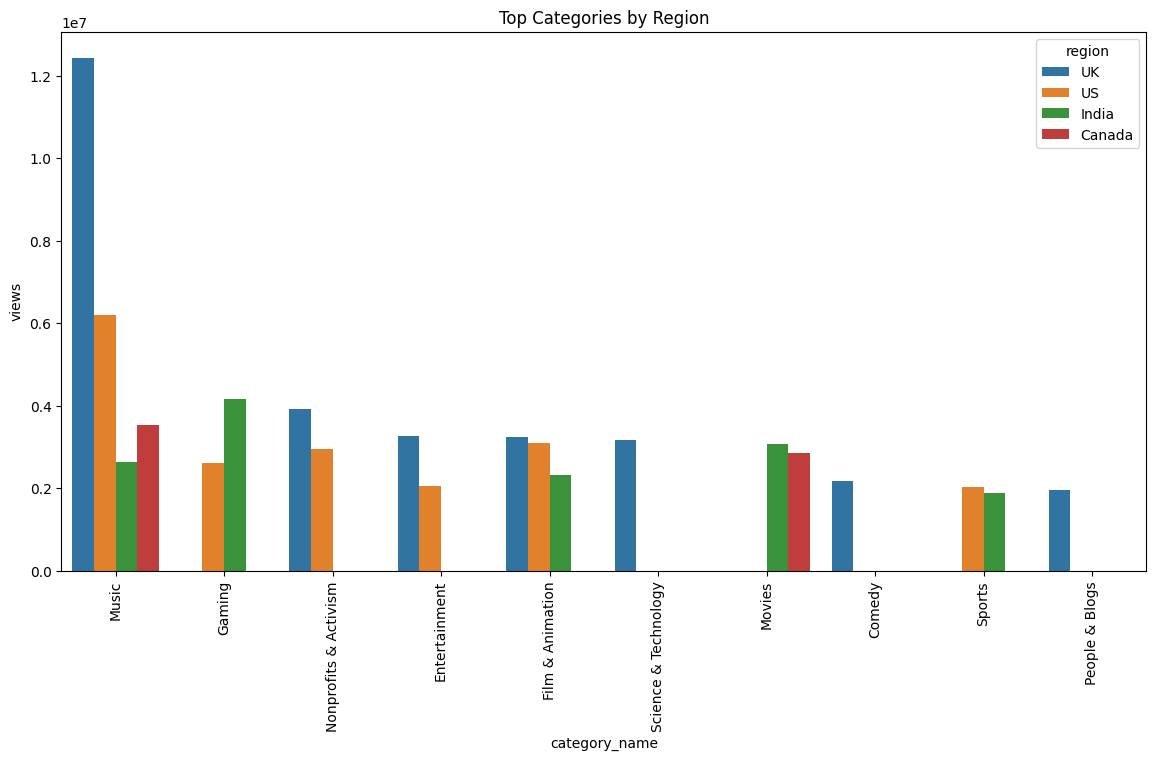

In [10]:
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=region_category.sort_values("views", ascending=False).head(20),
    x="category_name",
    y="views",
    hue="region"
)

plt.xticks(rotation=90)
plt.title("Top Categories by Region")
plt.show()

In [12]:
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce")
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")

In [25]:
# Count number of days each video trended
trending_duration = df.groupby("video_id")["trending_date"].count()

trending_duration.describe()

,trending_date
count,44761.000000
mean,1.320480
std,4.200509
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,678.000000


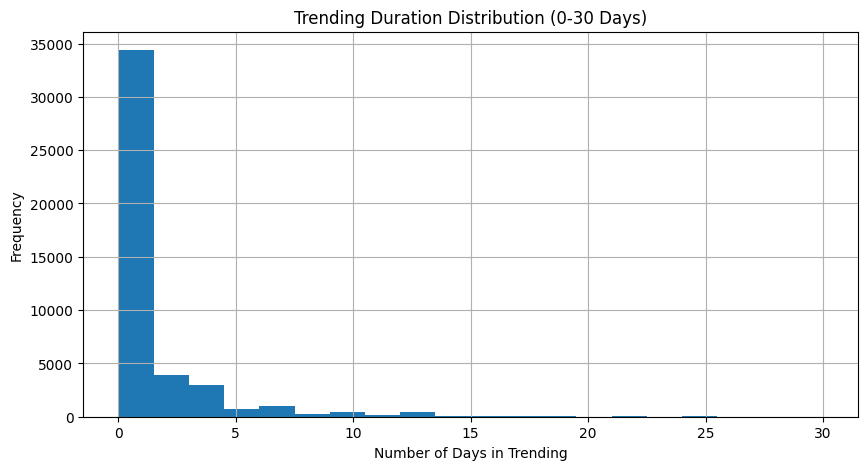

In [29]:
filtered_duration = trending_duration[trending_duration <= 30]

plt.figure(figsize=(10,5))
filtered_duration.hist(bins=20)

plt.title("Trending Duration Distribution (0-30 Days)")
plt.xlabel("Number of Days in Trending")
plt.ylabel("Frequency")
plt.show()

“Analysis shows that 75% of trending videos remain on the trending list for only 1 day, indicating that trending status is highly volatile and competitive.”

In [30]:
!pip install textblob

In [31]:
from textblob import TextBlob

In [32]:
df["title_sentiment"] = df["title"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df["title_sentiment"].describe()

,title_sentiment
count,158098.000000
mean,0.053444
std,0.252310
min,-1.000000
25%,0.000000
50%,0.000000
75%,0.068182
max,1.000000


“Sentiment analysis of video titles shows that trending videos tend to have neutral to slightly positive wording, with extreme emotional polarity being relatively rare.”

In [33]:
def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_category"] = df["title_sentiment"].apply(sentiment_label)

df["sentiment_category"].value_counts()

,count
sentiment_category,
Neutral,105503
Positive,36975
Negative,15620


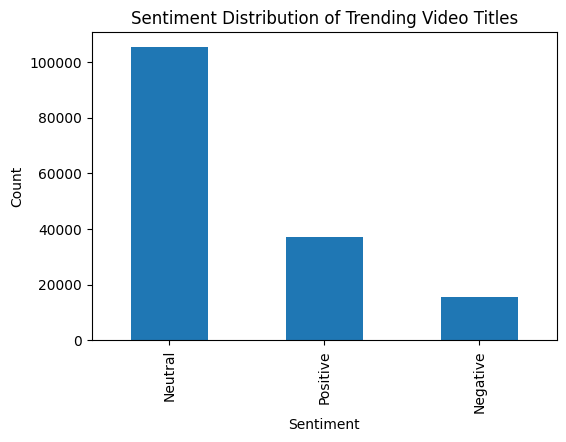

In [34]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment_category"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution of Trending Video Titles")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [35]:
df.groupby("sentiment_category")["views"].mean()

,views
sentiment_category,
Negative,3.767078e+06
Neutral,2.728312e+06
Positive,1.800055e+06


“Interestingly, videos with negative sentiment titles receive the highest average views (~3.76M), suggesting that emotionally charged or controversial wording may attract greater audience attention.”

In [36]:
category_views = df.groupby("category_name")["views"].mean().sort_values(ascending=False)

category_views.head(10)

,views
category_name,
Music,8.435177e+06
Movies,3.007296e+06
Film & Animation,2.596421e+06
Nonprofits & Activism,1.975326e+06
Entertainment,1.628033e+06
Sports,1.595446e+06
Science & Technology,1.519962e+06
Gaming,1.345976e+06
Comedy,1.255354e+06


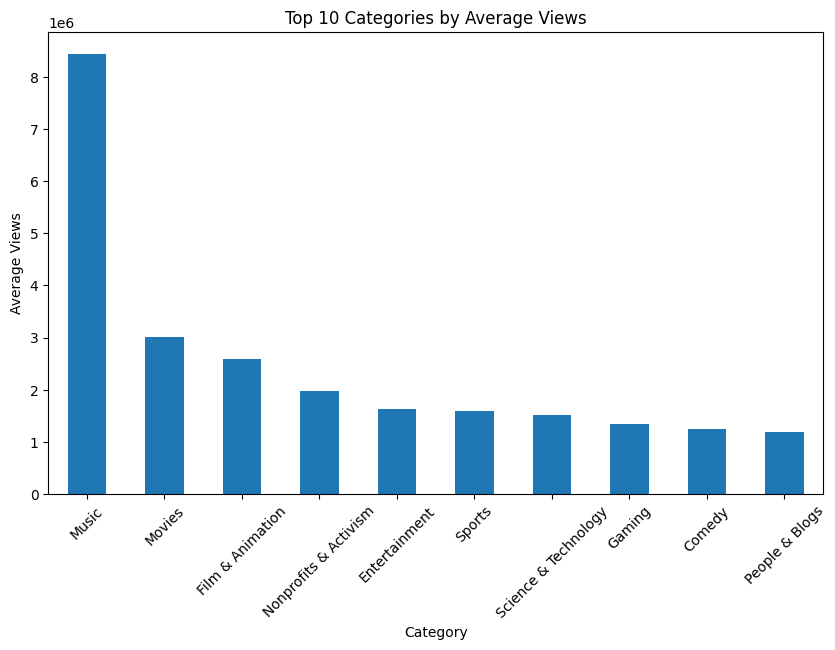

In [37]:
import matplotlib.pyplot as plt

top10 = category_views.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")

plt.title("Top 10 Categories by Average Views")
plt.xlabel("Category")
plt.ylabel("Average Views")
plt.xticks(rotation=45)
plt.show()

In [38]:
df["region"].unique()

array(['US', 'India', 'UK', 'Canada'], dtype=object)

In [39]:
region_views = df.groupby(["region", "category_name"])["views"].mean().reset_index()

region_views.head()

,region,category_name,views
0,Canada,Autos & Vehicles,5.667594e+05
1,Canada,Comedy,9.828886e+05
2,Canada,Education,5.366028e+05
3,Canada,Entertainment,1.016372e+06
4,Canada,Film & Animation,1.426729e+06


In [40]:
top_region = region_views.sort_values(["region", "views"], ascending=[True, False])

top_region.groupby("region").head(3)

,region,category_name,views
8,Canada,Music,3.532525e+06
7,Canada,Movies,2.853415e+06
10,Canada,Nonprofits & Activism,1.562184e+06
22,India,Gaming,4.162462e+06
24,India,Movies,3.065001e+06
25,India,Music,2.631116e+06
41,UK,Music,1.244444e+07
43,UK,Nonprofits & Activism,3.919981e+06
37,UK,Entertainment,3.264608e+06
57,US,Music,6.201003e+06


In [42]:
import sqlite3

# Create in-memory database
conn = sqlite3.connect(":memory:")

# Load dataframe into SQL
df.to_sql("youtube_data", conn, index=False, if_exists="replace")

# SQL query
query = """
SELECT category_name,
       AVG(views) as avg_views
FROM youtube_data
GROUP BY category_name
ORDER BY avg_views DESC
LIMIT 10;
"""

sql_result = pd.read_sql_query(query, conn)
sql_result

,category_name,avg_views
0,Music,8.435177e+06
1,Movies,3.007296e+06
2,Film & Animation,2.596421e+06
3,Nonprofits & Activism,1.975326e+06
4,Entertainment,1.628033e+06
5,Sports,1.595446e+06
6,Science & Technology,1.519962e+06
7,Gaming,1.345976e+06
8,Comedy,1.255354e+06
9,People & Blogs,1.186460e+06


In [43]:
df.to_csv("final_youtube_trending_data.csv", index=False)